In [1]:
import cv2
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


Step 1. Specify paths to images

In [10]:
video_path = "video1.mp4"  # заміни на назву свого відео

# Папка для результатів
output_dir = Path("tracking_output")
output_dir.mkdir(exist_ok=True)

kcf_dir = output_dir / "KCF"
csrt_dir = output_dir / "CSRT"

kcf_dir.mkdir(exist_ok=True)
csrt_dir.mkdir(exist_ok=True)


In [11]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise Exception("Video cannot be opened")


In [12]:
ret, first_frame = cap.read()
cap.release()

if not ret:
    raise Exception("Cannot read first frame")


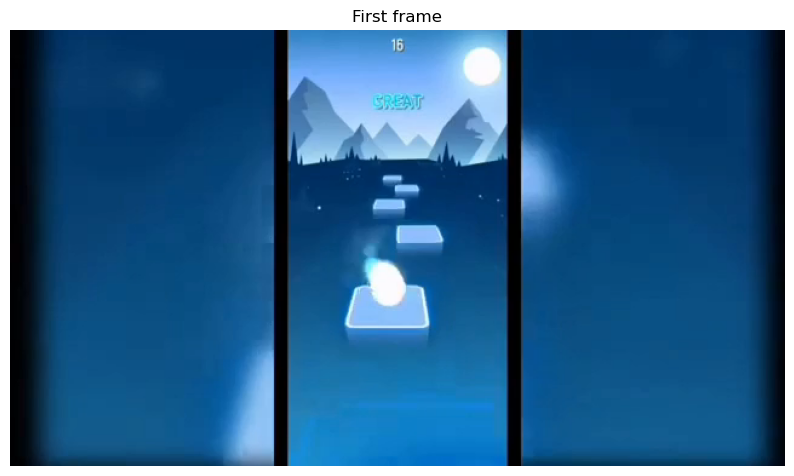

In [13]:
first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(first_frame_rgb)
plt.title("First frame")
plt.axis("off")
plt.show()


In [49]:
bbox = (296, 195, 30, 32)
print(first_frame.shape)

(360, 640, 3)


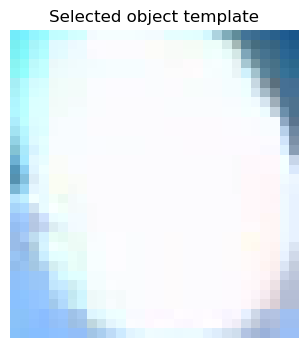

In [50]:
x, y, w, h = bbox

template = first_frame[y:y+h, x:x+w]

cv2.imwrite(str(output_dir / "template.jpg"), template)

template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 4))
plt.imshow(template_rgb)
plt.title("Selected object template")
plt.axis("off")
plt.show()


In [51]:
frame_with_bbox = first_frame.copy()

cv2.rectangle(
    frame_with_bbox,
    (x, y),
    (x + w, y + h),
    (0, 255, 0),
    2
)

frame_with_bbox_rgb = cv2.cvtColor(frame_with_bbox, cv2.COLOR_BGR2RGB)


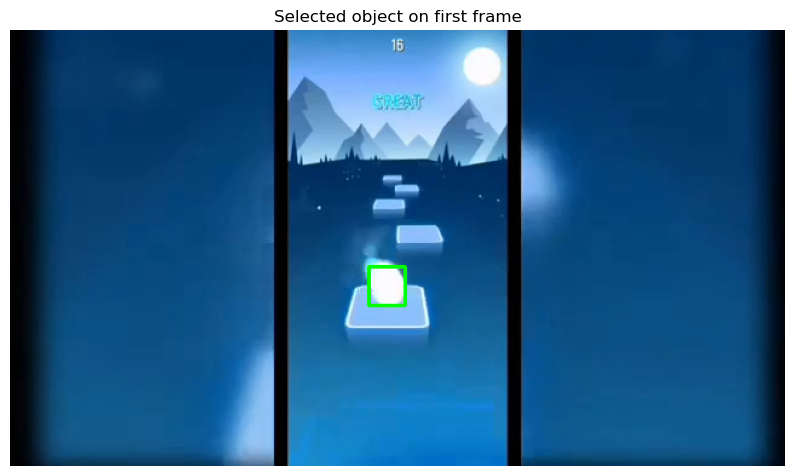

In [52]:
plt.figure(figsize=(10, 6))
plt.imshow(frame_with_bbox_rgb)
plt.title("Selected object on first frame")
plt.axis("off")
plt.show()


Step 2. Initialize the first tracker, for example KCF

In [53]:
def create_kcf_tracker():
    if hasattr(cv2, "legacy"):
        return cv2.legacy.TrackerKCF_create()
    else:
        return cv2.TrackerKCF_create()


In [54]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

if not ret:
    raise Exception("Cannot read first frame")

# Creating a KCF tracker
kcf_tracker = create_kcf_tracker()

# Initialize the tracker on the first frame
kcf_tracker.init(frame, bbox)

print("KCF tracker initialized")


KCF tracker initialized


Step 3. Run KCF tracker on 10–15 frames

In [55]:
num_frames = 15

kcf_results = []

frame_number = 0


Step 4. For each frame, draw a bbox and save the image

In [56]:
x, y, w, h = bbox

first_kcf_frame = frame.copy()

cv2.rectangle(
    first_kcf_frame,
    (x, y),
    (x + w, y + h),
    (0, 255, 0),
    2
)


array([[[ 3,  1,  1],
        [ 3,  1,  1],
        [ 3,  1,  1],
        ...,
        [11,  3,  0],
        [11,  3,  0],
        [11,  3,  0]],

       [[ 3,  1,  1],
        [ 3,  1,  1],
        [ 3,  1,  1],
        ...,
        [11,  3,  0],
        [11,  3,  0],
        [11,  3,  0]],

       [[ 3,  1,  1],
        [ 3,  1,  1],
        [ 3,  1,  1],
        ...,
        [11,  3,  0],
        [11,  3,  0],
        [11,  3,  0]],

       ...,

       [[ 3,  1,  0],
        [ 3,  1,  0],
        [ 3,  1,  0],
        ...,
        [17,  5,  0],
        [14,  3,  0],
        [14,  3,  0]],

       [[ 3,  1,  0],
        [ 3,  1,  0],
        [ 3,  1,  0],
        ...,
        [17,  5,  0],
        [14,  3,  0],
        [14,  3,  0]],

       [[ 3,  1,  0],
        [ 3,  1,  0],
        [ 3,  1,  0],
        ...,
        [17,  5,  0],
        [14,  3,  0],
        [14,  3,  0]]], shape=(360, 640, 3), dtype=uint8)

In [57]:
cv2.putText(
    first_kcf_frame,
    "KCF frame 0",
    (x, y - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (0, 255, 0),
    2
)

cv2.imwrite(str(kcf_dir / "frame_000.jpg"), first_kcf_frame)

True

In [58]:
kcf_results.append({
    "tracker": "KCF",
    "frame": 0,
    "success": True,
    "x": x,
    "y": y,
    "w": w,
    "h": h,
    "time_ms": 0
})


In [59]:
for i in range(1, num_frames + 1):
    ret, frame = cap.read()
    
    if not ret:
        break
    
    start_time = time.time()
    
    success, new_bbox = kcf_tracker.update(frame)
    
    end_time = time.time()
    time_ms = (end_time - start_time) * 1000
    
    output_frame = frame.copy()
    
    if success:
        x, y, w, h = [int(v) for v in new_bbox]
        
        cv2.rectangle(
            output_frame,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )
        
        cv2.putText(
            output_frame,
            f"KCF frame {i}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )
    else:
        x, y, w, h = np.nan, np.nan, np.nan, np.nan
        
        cv2.putText(
            output_frame,
            "KCF tracking failed",
            (30, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )
    
    save_path = kcf_dir / f"frame_{i:03d}.jpg"
    cv2.imwrite(str(save_path), output_frame)


In [60]:
kcf_results.append({
        "tracker": "KCF",
        "frame": i,
        "success": success,
        "x": x,
        "y": y,
        "w": w,
        "h": h,
        "time_ms": time_ms
    })

cap.release()

print("KCF tracking finished")


KCF tracking finished


In [61]:
kcf_df = pd.DataFrame(kcf_results)
kcf_df

,tracker,frame,success,x,y,w,h,time_ms
0,KCF,0,True,296.0,195.0,30.0,32.0,0.000000
1,KCF,15,False,NaN,NaN,NaN,NaN,0.620842


Optional: find the same person in a group photo

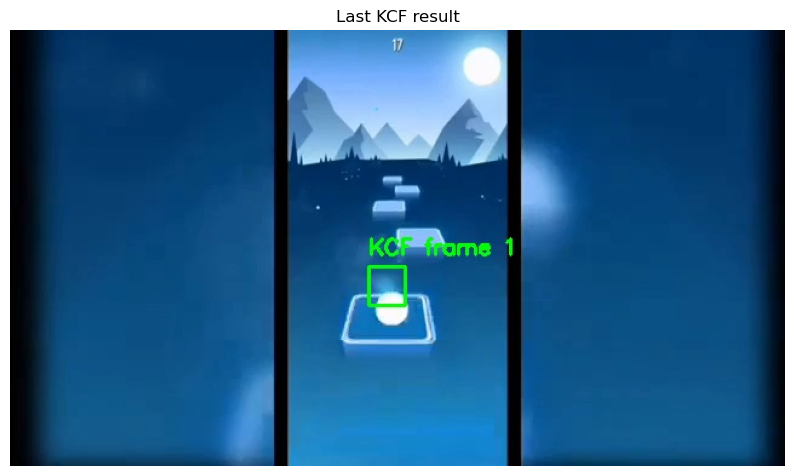

In [62]:
last_kcf_image = cv2.imread(str(kcf_dir / f"frame_{len(kcf_df)-1:03d}.jpg"))
last_kcf_image_rgb = cv2.cvtColor(last_kcf_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(last_kcf_image_rgb)
plt.title("Last KCF result")
plt.axis("off")
plt.show()


Step 5. Select another tracker, for example OpenCV CSRT, and repeat Steps 2–4

In [66]:
def create_csrt_tracker():
    if hasattr(cv2, "legacy"):
        return cv2.legacy.TrackerCSRT_create()
    else:
        return cv2.TrackerCSRT_create()


In [67]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

if not ret:
    raise Exception("Cannot read first frame")


In [68]:
csrt_tracker = create_csrt_tracker()

csrt_tracker.init(frame, bbox)

print("CSRT tracker initialized")


CSRT tracker initialized


In [69]:
csrt_results = []

In [70]:
x, y, w, h = bbox

first_csrt_frame = frame.copy()

cv2.rectangle(
   first_csrt_frame,
   (x, y),
   (x + w, y + h),
   (255, 0, 0),
   2
)

cv2.putText(
   first_csrt_frame,
   "CSRT frame 0",
   (x, y - 10),
   cv2.FONT_HERSHEY_SIMPLEX,
   0.6,
   (255, 0, 0),
   2
)

cv2.imwrite(str(csrt_dir / "frame_000.jpg"), first_csrt_frame)

csrt_results.append({
   "tracker": "CSRT",
   "frame": 0,
   "success": True,
   "x": x,
   "y": y,
   "w": w,
   "h": h,
   "time_ms": 0
})


In [71]:
for i in range(1, num_frames + 1):
    ret, frame = cap.read()
    
    if not ret:
        break
    
    start_time = time.time()
    
    success, new_bbox = csrt_tracker.update(frame)
    
    end_time = time.time()
    time_ms = (end_time - start_time) * 1000
    
    output_frame = frame.copy()
    
    if success:
        x, y, w, h = [int(v) for v in new_bbox]
        
        cv2.rectangle(
            output_frame,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )
        
        cv2.putText(
            output_frame,
            f"CSRT frame {i}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )
    else:
        x, y, w, h = np.nan, np.nan, np.nan, np.nan
        
        cv2.putText(
            output_frame,
            "CSRT tracking failed",
            (30, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )
    
    save_path = csrt_dir / f"frame_{i:03d}.jpg"
    cv2.imwrite(str(save_path), output_frame)
    
    csrt_results.append({
        "tracker": "CSRT",
        "frame": i,
        "success": success,
        "x": x,
        "y": y,
        "w": w,
        "h": h,
        "time_ms": time_ms
    })

cap.release()

print("CSRT tracking finished")


CSRT tracking finished


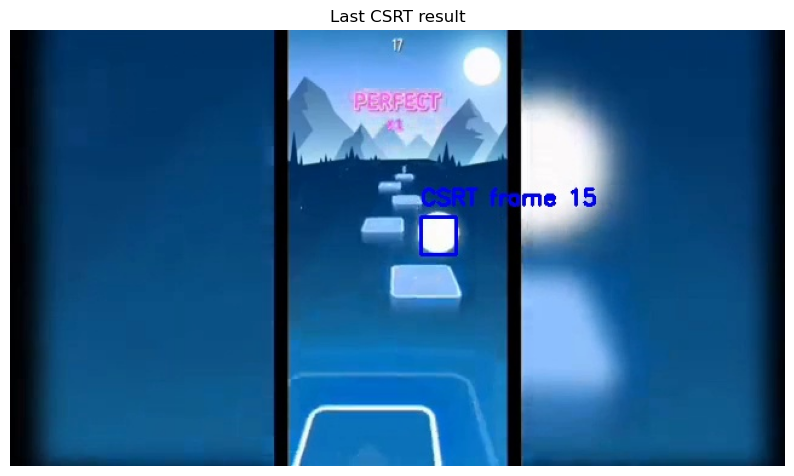

In [72]:
csrt_df = pd.DataFrame(csrt_results)
csrt_df

last_csrt_image = cv2.imread(str(csrt_dir / f"frame_{len(csrt_df)-1:03d}.jpg"))
last_csrt_image_rgb = cv2.cvtColor(last_csrt_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(last_csrt_image_rgb)
plt.title("Last CSRT result")
plt.axis("off")
plt.show()


Step 6. Compare results

<Axes: xlabel='tracker'>

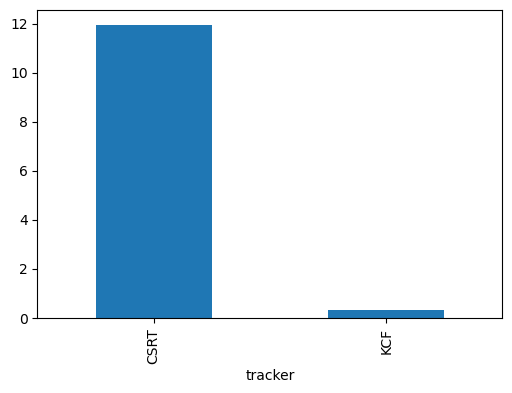

In [73]:
# Combining the results of two trackers

all_results = pd.concat([kcf_df, csrt_df], ignore_index=True)

all_results
# Comparison of average tracker uptime

comparison_time = all_results.groupby("tracker")["time_ms"].mean()

comparison_time

comparison_success = all_results.groupby("tracker")["success"].sum()

comparison_success

comparison_time.plot(kind="bar", figsize=(6, 4))


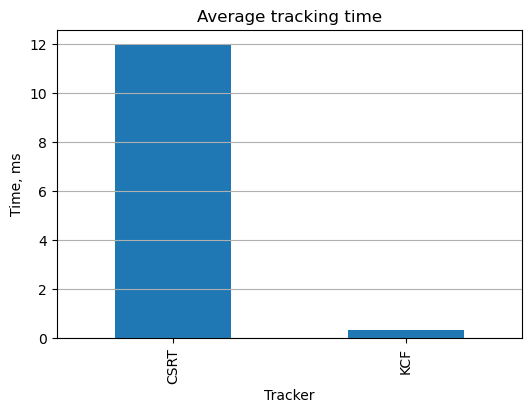

In [79]:
comparison_time.plot(kind="bar", figsize=(6, 4))

plt.title("Average tracking time")
plt.ylabel("Time, ms")
plt.xlabel("Tracker")
plt.grid(axis="y")

plt.show()

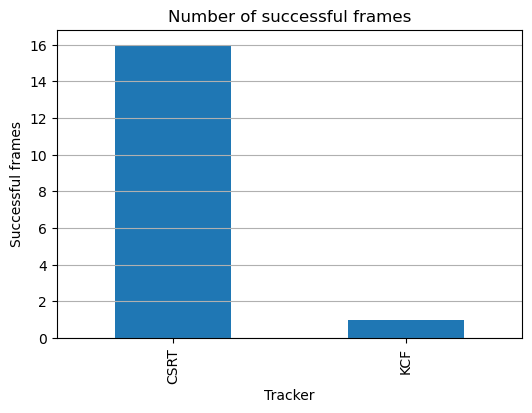

In [75]:
comparison_success.plot(kind="bar", figsize=(6, 4))

plt.title("Number of successful frames")
plt.ylabel("Successful frames")
plt.xlabel("Tracker")
plt.grid(axis="y")
plt.show()


In [77]:
kcf_avg_time = kcf_df["time_ms"].mean()
csrt_avg_time = csrt_df["time_ms"].mean()

kcf_success = kcf_df["success"].sum()
csrt_success = csrt_df["success"].sum()

print("Comparison of KCF and CSRT trackers")
print(f"KCF average time: {kcf_avg_time:.2f} ms")
print(f"CSRT average time: {csrt_avg_time:.2f} ms")
print()
print(f"KCF successful frames: {kcf_success}")
print(f"CSRT successful frames: {csrt_success}")
print()

if kcf_avg_time < csrt_avg_time:
   print("KCF is faster than CSRT.")
else:
   print("CSRT is faster than KCF.")

if kcf_success > csrt_success:
   print("KCF tracked the object successfully in more frames.")
elif csrt_success > kcf_success:
   print("CSRT tracked the object successfully in more frames.")
else:
   print("Both trackers tracked the object successfully in the same number of frames.")




Comparison of KCF and CSRT trackers
KCF average time: 0.31 ms
CSRT average time: 11.97 ms

KCF successful frames: 1
CSRT successful frames: 16

KCF is faster than CSRT.
CSRT tracked the object successfully in more frames.


I used two trackers: KCF and CSRT.

The KCF tracker was faster because it needed less time to process each frame. 
However, it can be less accurate when the object changes its size, rotates, or when the background is complicated.

The CSRT tracker was slower than KCF, but it usually produced a more stable bounding box. 
It followed the object more accurately when the object moved or changed appearance.

In my experiment, both trackers were able to track the selected object for around 15 frames. 
The main difference was that KCF was faster, while CSRT was more accurate and stable.

Overall, CSRT performed better in terms of tracking quality, but KCF performed better in terms of speed.
